In [ ]:
def generate_village_data(n_pits=30):
    np.random.seed(42)
    # Center of a simulated village in Northern Ghana
    center_lat, center_lon = 10.3, -0.8

    data = {
        'pit_id': [f'PIT-{i:03d}' for i in range(n_pits)],
        'lat': center_lat + np.random.normal(0, 0.005, n_pits),
        'lon': center_lon + np.random.normal(0, 0.005, n_pits),
        'fill_mm': np.random.randint(500, 2500, n_pits),
        'pit_depth_mm': 2500,
        'dist_to_well': np.random.uniform(5, 150, n_pits), # meters
        'soil_leach_index': np.random.randint(1, 6, n_pits), # 1-5
        'vadose_depth_m': np.random.uniform(2, 15, n_pits),
        'latrine_cond_score': np.random.randint(1, 6, n_pits), # 1-5
        'forecast_mm': np.random.uniform(0, 60, n_pits) # CHIRPS proxy
    }
    return pd.DataFrame(data)

df_village = generate_village_data()

In [ ]:
class SaniFlowEngine:
    def __init__(self):
        # CALIBRATED WEIGHTS (Najat's Input)
        self.w = {'fill': 0.35, 'rain': 0.25, 'dist': 0.20, 'leach': 0.10, 'vadose': 0.05, 'cond': 0.05}

    def compute_risk(self, row):
        # 1. Normalization
        f_fill = row['fill_mm'] / row['pit_depth_mm']
        f_rain = np.clip(row['forecast_mm'] / 50.0, 0, 1) # 50mm threshold

        # 2. Exponential Decay: Risk drops fast after 30m
        f_dist = np.exp(-row['dist_to_well'] / 30)

        # 3. Categorical Normalization (1-5 scales)
        f_leach = row['soil_leach_index'] / 5.0
        f_vadose = 1 - (row['vadose_depth_m'] / 15.0) # Inverse: shallower is riskier
        f_cond = row['latrine_cond_score'] / 5.0

        # 4. Final Priority Score (S)
        score = (self.w['fill'] * f_fill + self.w['rain'] * f_rain +
                 self.w['dist'] * f_dist + self.w['leach'] * f_leach +
                 self.w['vadose'] * f_vadose + self.w['cond'] * f_cond)

        return np.clip(score, 0, 1)

engine = SaniFlowEngine()
df_village['priority_score'] = df_village.apply(engine.compute_risk, axis=1)

In [ ]:
# !pip install xgboost geopandas folium scikit-learn
import pandas as pd
import numpy as np
import xgboost as xgb
import folium
from datetime import datetime, timedelta
import json

print("SaniFlow Brain Layer: Environment Initialized.")

SaniFlow Brain Layer: Environment Initialized.


In [ ]:
def optimize_dispatch(df, truck_capacity=10, hours_limit=48):
    # Sort by risk score descending
    df_sorted = df.sort_values(by='priority_score', ascending=False).copy()

    # Simple simulated service time: 2 hours per pit
    service_time = 2
    total_time = 0
    dispatched = []

    for idx, row in df_sorted.iterrows():
        if total_time + service_time <= hours_limit and len(dispatched) < truck_capacity:
            total_time += service_time
            dispatched.append(row['pit_id'])
            df_sorted.at[idx, 'status'] = 'DISPATCHED'
        else:
            df_sorted.at[idx, 'status'] = 'WAITING'

    return df_sorted

df_final = optimize_dispatch(df_village)

In [ ]:
def create_pitch_map(df):
    m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=15)

    for _, row in df.iterrows():
        color = 'red' if row['priority_score'] > 0.7 else 'orange' if row['priority_score'] > 0.4 else 'green'
        icon = 'truck' if row['status'] == 'DISPATCHED' else 'info-sign'

        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=f"ID: {row['pit_id']}<br>Score: {row['priority_score']:.2f}<br>Status: {row['status']}",
            icon=folium.Icon(color=color, icon=icon)
        ).add_to(m)
    return m

pitch_map = create_pitch_map(df_final)
pitch_map

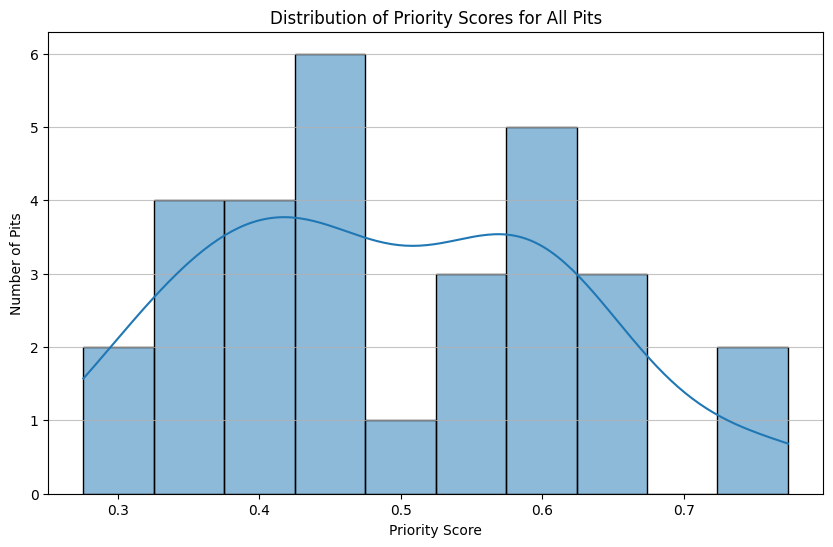

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_village['priority_score'], bins=10, kde=True)
plt.title('Distribution of Priority Scores for All Pits')
plt.xlabel('Priority Score')
plt.ylabel('Number of Pits')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df_high_priority = df_final[df_final['priority_score'] > 0.6]
filtered_pitch_map = create_pitch_map(df_high_priority)
filtered_pitch_map

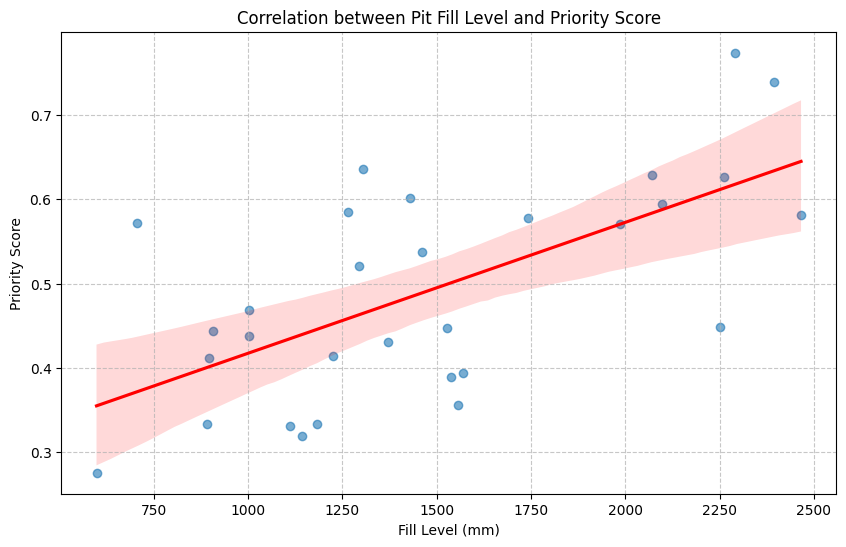

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='fill_mm', y='priority_score', data=df_village, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlation between Pit Fill Level and Priority Score')
plt.xlabel('Fill Level (mm)')
plt.ylabel('Priority Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
correlation = df_village['fill_mm'].corr(df_village['priority_score'])
print(f"Correlation between 'fill_mm' and 'priority_score': {correlation:.4f}")

Correlation between 'fill_mm' and 'priority_score': 0.6407


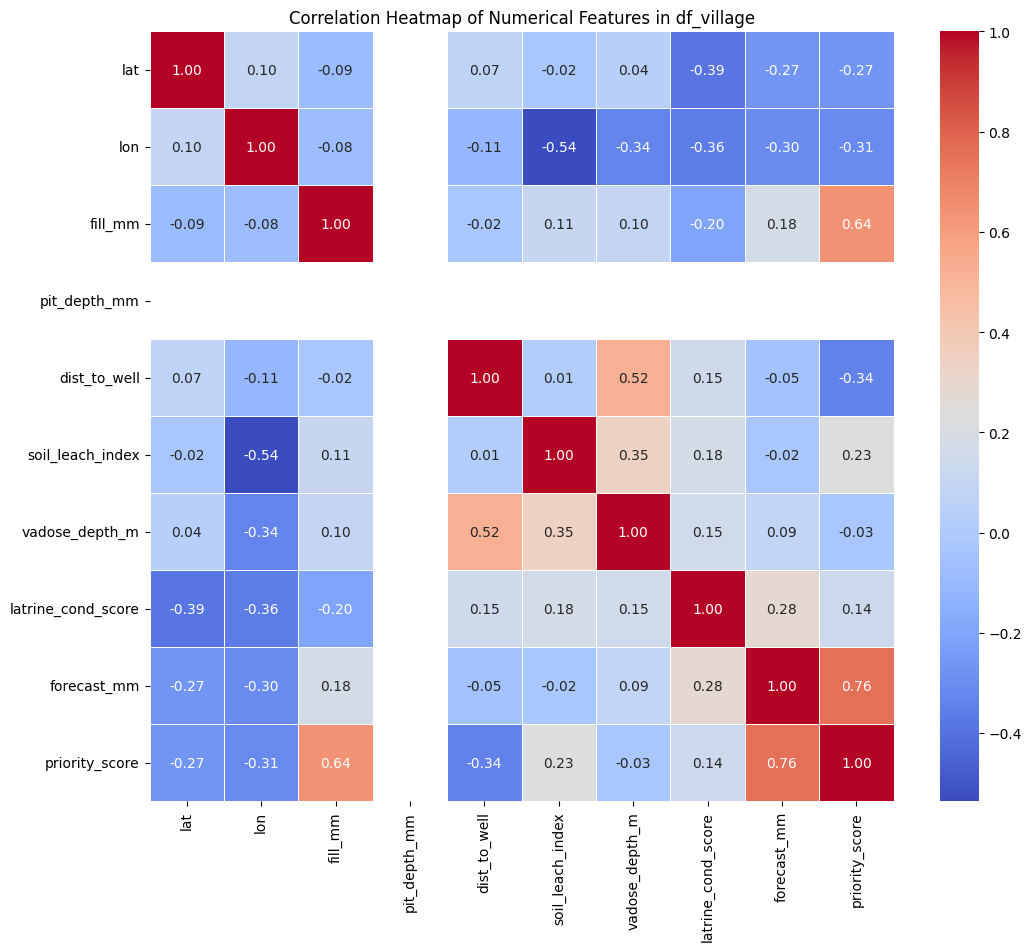

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df_village.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features in df_village')
plt.show()

In [ ]:
import numpy as np

class SaniFlowCore:
    """
    SaniFlow Brain Layer v1.0
    Implements Hybrid Heuristic-ML Priority Indexing for Climate-Resilient Sanitation.
    """
    def __init__(self, weights=None):
        self.weights = weights or {
            'fill': 0.35, 'rain': 0.25, 'dist': 0.20,
            'leach': 0.10, 'vadose': 0.05, 'cond': 0.05
        }

    def get_priority_index(self, telemetry, static_data):
        """
        Calculates normalized risk score (0.0 - 1.0).
        """
        # Linear normalization for fill and rain
        f_fill = telemetry['fill_mm'] / static_data['pit_depth_mm']
        f_rain = np.clip(telemetry['forecast_mm'] / 50.0, 0, 1)

        # Exponential Spatial Decay for Contamination Plume (Lambda = 30m)
        f_dist = np.exp(-static_data['dist_to_well_m'] / 30)

        # Ordinal weights for geological and structural factors
        f_leach = static_data['leach_index'] / 5.0
        f_vadose = 1 - (static_data['vadose_depth_m'] / 15.0)
        f_cond = static_data['condition_index'] / 5.0

        score = (self.weights['fill'] * f_fill + self.weights['rain'] * f_rain +
                 self.weights['dist'] * f_dist + self.weights['leach'] * f_leach +
                 self.weights['vadose'] * f_vadose + self.weights['cond'] * f_cond)

        return float(np.clip(score, 0, 1))

# Example Usage:
# core = SaniFlowCore()
# score = core.get_priority_index(telemetry_packet, asset_registry_data)

In [ ]:
# Create an instance of the SaniFlowCore engine
saniflow_core_engine = SaniFlowCore()

# Define a sample telemetry packet and static data for a new pit
telemetry_packet = {
    'fill_mm': 2000,       # Current fill level in mm
    'forecast_mm': 30      # Forecasted rainfall in mm
}

static_data = {
    'pit_depth_mm': 2500,     # Total depth of the pit in mm
    'dist_to_well_m': 25,     # Distance to the nearest well in meters
    'leach_index': 4,         # Soil leaching index (1-5, higher is riskier)
    'vadose_depth_m': 5,      # Depth to vadose zone in meters (shallower is riskier)
    'condition_index': 3      # Latrine condition score (1-5, higher is riskier)
}

# Get the priority index for the new pit
new_pit_priority_score = saniflow_core_engine.get_priority_index(telemetry_packet, static_data)

print(f"Priority Score for the new pit: {new_pit_priority_score:.4f}")

Priority Score for the new pit: 0.6603


In [ ]:
import numpy as np

# Create a new instance of SaniFlowCore (if not already created or if weights might have changed)
saniflow_validator = SaniFlowCore()

def calculate_saniflow_core_score(row, engine):
    telemetry_packet = {
        'fill_mm': row['fill_mm'],
        'forecast_mm': row['forecast_mm']
    }
    static_data = {
        'pit_depth_mm': row['pit_depth_mm'],
        'dist_to_well_m': row['dist_to_well'],
        'leach_index': row['soil_leach_index'],
        'vadose_depth_m': row['vadose_depth_m'],
        'condition_index': row['latrine_cond_score']
    }
    return engine.get_priority_index(telemetry_packet, static_data)

df_village['validated_priority_score'] = df_village.apply(lambda row: calculate_saniflow_core_score(row, saniflow_validator), axis=1)

In [ ]:
# Compare the original priority_score with the newly calculated one
df_comparison = df_village[['pit_id', 'priority_score', 'validated_priority_score']].copy()
df_comparison['score_difference'] = np.abs(df_comparison['priority_score'] - df_comparison['validated_priority_score'])

display(df_comparison.head())

# Check for any significant differences
max_diff = df_comparison['score_difference'].max()
print(f"Maximum absolute difference between original and validated scores: {max_diff:.8f}")

if max_diff < 1e-9:
    print("Validation successful: The SaniFlowCore model produces identical scores (within floating point precision) to the original calculation.")
else:
    print(f"Validation detected differences. Maximum difference: {max_diff}")

,pit_id,priority_score,validated_priority_score,score_difference
0,PIT-000,0.601118,0.601118,0.0
1,PIT-001,0.356664,0.356664,0.0
2,PIT-002,0.394165,0.394165,0.0
3,PIT-003,0.437752,0.437752,0.0
4,PIT-004,0.444267,0.444267,0.0


Maximum absolute difference between original and validated scores: 0.00000000
Validation successful: The SaniFlowCore model produces identical scores (within floating point precision) to the original calculation.


### Sensitivity Analysis: Impact of Rainfall Forecast on Priority Score

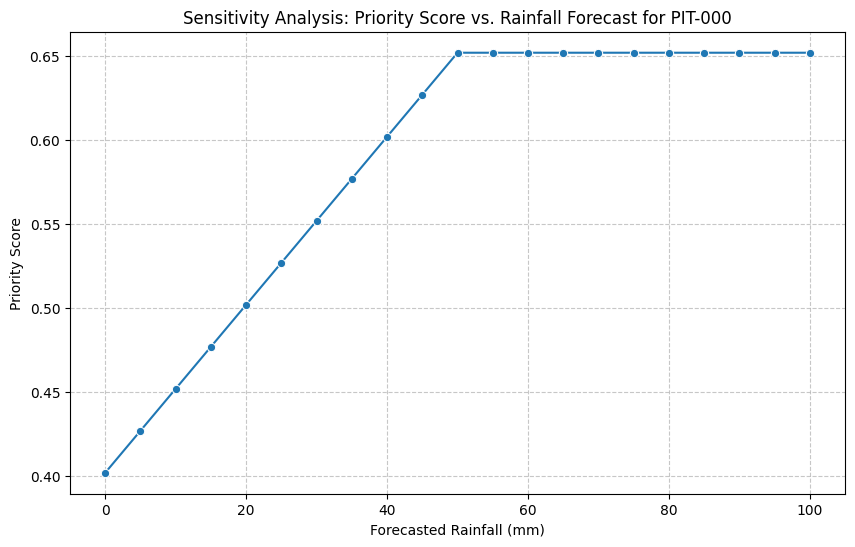

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a pit for sensitivity analysis (e.g., PIT-000)
pit_id_for_analysis = 'PIT-000'
pit_data = df_village[df_village['pit_id'] == pit_id_for_analysis].iloc[0]

# Define a range of rainfall forecasts
rainfall_forecasts = np.arange(0, 101, 5) # 0 to 100mm in steps of 5mm

# Initialize a list to store results
sensitivity_results = []

# Re-use the SaniFlowCore instance or create a new one if needed
saniflow_analyzer = SaniFlowCore()

for forecast in rainfall_forecasts:
    # Prepare telemetry and static data for the specific pit
    telemetry_packet_sa = {
        'fill_mm': pit_data['fill_mm'],
        'forecast_mm': forecast
    }
    static_data_sa = {
        'pit_depth_mm': pit_data['pit_depth_mm'],
        'dist_to_well_m': pit_data['dist_to_well'],
        'leach_index': pit_data['soil_leach_index'],
        'vadose_depth_m': pit_data['vadose_depth_m'],
        'condition_index': pit_data['latrine_cond_score']
    }

    # Calculate the priority score
    score = saniflow_analyzer.get_priority_index(telemetry_packet_sa, static_data_sa)
    sensitivity_results.append({'forecast_mm': forecast, 'priority_score': score})

# Convert results to a DataFrame for plotting
df_sensitivity = pd.DataFrame(sensitivity_results)

# Plot the sensitivity analysis
plt.figure(figsize=(10, 6))
sns.lineplot(x='forecast_mm', y='priority_score', data=df_sensitivity, marker='o')
plt.title(f'Sensitivity Analysis: Priority Score vs. Rainfall Forecast for {pit_id_for_analysis}')
plt.xlabel('Forecasted Rainfall (mm)')
plt.ylabel('Priority Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
summary_by_condition = df_village.groupby('latrine_cond_score')['priority_score'].agg(
    ['mean', 'median', 'min', 'max', 'count']
).reset_index()

print("Summary of Priority Scores Grouped by Latrine Condition Score:")
display(summary_by_condition)

Summary of Priority Scores Grouped by Latrine Condition Score:


,latrine_cond_score,mean,median,min,max,count
0,1,0.470742,0.448621,0.333095,0.601118,9
1,2,0.520989,0.494333,0.356664,0.738627,4
2,3,0.470534,0.437752,0.319440,0.773753,7
3,4,0.500199,0.549090,0.275790,0.635583,8
4,5,0.581854,0.581854,0.536996,0.626711,2


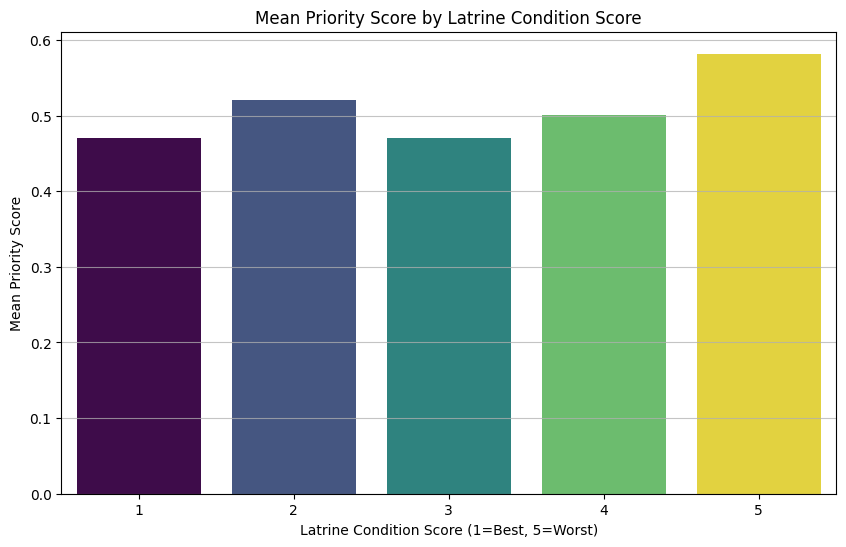

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='latrine_cond_score', y='mean', data=summary_by_condition, palette='viridis', hue='latrine_cond_score', legend=False)
plt.title('Mean Priority Score by Latrine Condition Score')
plt.xlabel('Latrine Condition Score (1=Best, 5=Worst)')
plt.ylabel('Mean Priority Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()

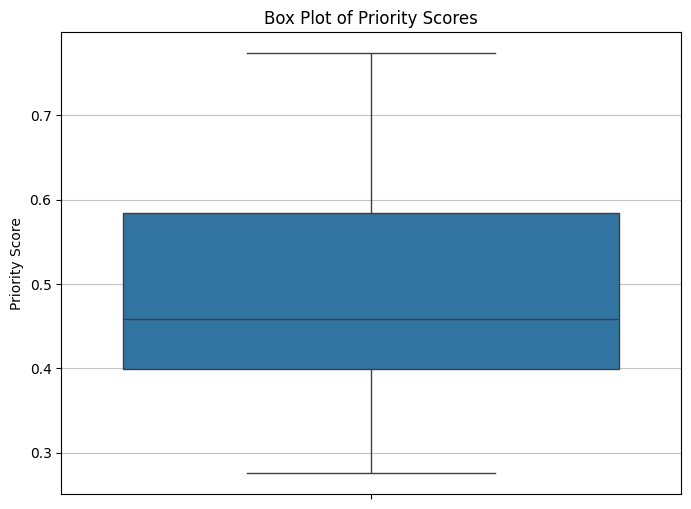

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_village['priority_score'])
plt.title('Box Plot of Priority Scores')
plt.ylabel('Priority Score')
plt.grid(axis='y', alpha=0.75)
plt.show()